# Phase 1: Data Engineering & Preprocessing

In [11]:
## 1.1 Environment Setup & Dependencies

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, make_scorer, confusion_matrix, log_loss, roc_auc_score
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# --- Define custom specificity metric for cross-validation ---
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

In [12]:
# 1.2 Data Ingestion
df = pd.read_csv('FitnessAppUsersDataset.csv')
print("First few rows of the dataset:")
display(df.head())

## 1.3 Data Integrity & Imputation
df = df.drop(columns=['ID'])
print(f"\nShape after removing ID: {df.shape}")

# Create a 95% random sample using a fixed random seed and display shape.
RANDOM_SEED = 42
df_sample = df.sample(frac=0.95, random_state=RANDOM_SEED)
print(f"Shape of the random sample: {df_sample.shape}")

# Use only the random sample dataset for the rest of the project.

First few rows of the dataset:


,ID,Age,MonthlyActiveDays,AvgSessionDuration,WorkoutsCompleted,SocialEngagementScore,SubscriptionTier,InAppPurchases,DeviceType,Churned,LifetimeValue,Cluster
0,1,30,6,11,3,19,Free,0.32,iOS,1,63.97,Cluster 4
1,2,48,4,44,8,23,Basic,23.78,iOS,1,197.34,Cluster 2
2,3,24,12,28,2,82,Free,41.38,iOS,1,395.08,Cluster 3
3,4,25,13,11,0,86,Basic,55.41,Android,0,203.84,Cluster 3
4,5,36,27,88,29,98,Premium,300.17,iOS,0,1882.55,Cluster 1



Shape after removing ID: (2000, 11)
Shape of the random sample: (1900, 11)


# Phase 2: Behavioral Analysis & Segmentation

In [13]:
# Create a table showing min, max, mean, median, std. dev. for numeric variables
numeric_cols = df_sample.select_dtypes(include=[np.number]).columns
b1_table = df_sample[numeric_cols].agg(['min', 'max', 'mean', 'median', 'std']).T
print("Numeric Variables Summary:")
display(b1_table)

# Create a table showing count and proportions for categorical variables
cat_cols = df_sample.select_dtypes(include=['object']).columns
print("\nCategorical Variables Summary:")
for col in cat_cols:
    counts = df_sample[col].value_counts()
    props = df_sample[col].value_counts(normalize=True)
    summary_df = pd.DataFrame({'Count': counts, 'Proportion': props})
    print(f"\n{col}:")
    display(summary_df)

# Create a correlation matrix of the numerical variables
correlation_matrix = df_sample[numeric_cols].corr()
print("\nCorrelation Matrix:")
display(correlation_matrix)

Numeric Variables Summary:


,min,max,mean,median,std
Age,18.00,55.00,32.975789,32.000,7.792831
MonthlyActiveDays,1.00,30.00,13.293684,10.000,9.778487
AvgSessionDuration,5.00,90.00,35.600000,26.000,24.559607
WorkoutsCompleted,0.00,30.00,8.247368,3.000,9.927163
SocialEngagementScore,0.00,100.00,48.538421,30.000,34.585138
InAppPurchases,0.00,399.26,77.321805,23.020,111.157399
Churned,0.00,1.00,0.562632,1.000,0.496192
LifetimeValue,0.17,1999.01,479.018195,160.725,620.553431



Categorical Variables Summary:

SubscriptionTier:


,Count,Proportion
SubscriptionTier,,
Free,955,0.502632
Premium,487,0.256316
Basic,458,0.241053



DeviceType:


,Count,Proportion
DeviceType,,
iOS,1036,0.545263
Android,864,0.454737



Cluster:


,Count,Proportion
Cluster,,
Cluster 2,480,0.252632
Cluster 1,476,0.250526
Cluster 3,473,0.248947
Cluster 4,471,0.247895



Correlation Matrix:


,Age,MonthlyActiveDays,AvgSessionDuration,WorkoutsCompleted,SocialEngagementScore,InAppPurchases,Churned,LifetimeValue
Age,1.000000,0.081796,0.328555,0.266271,-0.094401,0.116556,-0.069879,0.115638
MonthlyActiveDays,0.081796,1.000000,0.808456,0.811968,0.853975,0.833916,-0.622745,0.887323
AvgSessionDuration,0.328555,0.808456,1.000000,0.929901,0.532815,0.846316,-0.551790,0.887063
WorkoutsCompleted,0.266271,0.811968,0.929901,1.000000,0.515210,0.879839,-0.562690,0.920907
SocialEngagementScore,-0.094401,0.853975,0.532815,0.515210,1.000000,0.618985,-0.532506,0.669339
InAppPurchases,0.116556,0.833916,0.846316,0.879839,0.618985,1.000000,-0.567537,0.882329
Churned,-0.069879,-0.622745,-0.551790,-0.562690,-0.532506,-0.567537,1.000000,-0.601479
LifetimeValue,0.115638,0.887323,0.887063,0.920907,0.669339,0.882329,-0.601479,1.000000


# Phase 3: Predictive Algorithm Architecture

standardized_df created successfully.

kMeans Clustering Results:

--- For k = 3 --- (Silhouette Score: 0.4446)


,Count,Proportion
Cluster_3,,
2,941,0.495263
0,483,0.254211
1,476,0.250526



--- For k = 4 --- (Silhouette Score: 0.3350)


,Count,Proportion
Cluster_4,,
2,941,0.495263
0,483,0.254211
3,246,0.129474
1,230,0.121053



--- For k = 5 --- (Silhouette Score: 0.4558)


,Count,Proportion
Cluster_5,,
0,480,0.252632
4,473,0.248947
2,471,0.247895
3,246,0.129474
1,230,0.121053


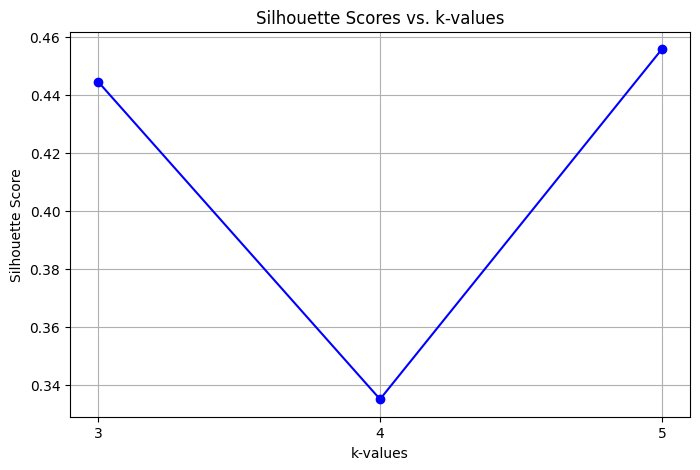

The k-value that maximizes the silhouette score is k = 5.


In [14]:
# One-hot encode categorical variables, apply z-score scaling to numeric, leave dummies unchanged.
# Apply Reference Category Encoding (drop_first=True to avoid multicollinearity)
df_encoded = pd.get_dummies(df_sample, columns=cat_cols, drop_first=True)

# Identify strictly numeric features (excluding the target and the new dummy variables)
numeric_features = df_sample.select_dtypes(include=[np.number]).columns.drop('Churned')

# Scale the numeric features
scaler = StandardScaler()
standardized_df = df_encoded.copy()
standardized_df[numeric_features] = scaler.fit_transform(standardized_df[numeric_features])
print("standardized_df created successfully.")

# Run kMeans separately for k=3, 4, 5 using a fixed random seed.
features_for_clustering = standardized_df.drop('Churned', axis=1) # Exclude target from clustering
k_values = [3, 4, 5]
silhouette_scores = []

print("\nkMeans Clustering Results:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init='auto')
    cluster_labels = kmeans.fit_predict(features_for_clustering)
    score = silhouette_score(features_for_clustering, cluster_labels)
    silhouette_scores.append(score)

    # Store cluster labels
    standardized_df[f'Cluster_{k}'] = cluster_labels

    # Display count and proportion
    counts = standardized_df[f'Cluster_{k}'].value_counts()
    props = standardized_df[f'Cluster_{k}'].value_counts(normalize=True)
    cluster_summary = pd.DataFrame({'Count': counts, 'Proportion': props})
    print(f"\n--- For k = {k} --- (Silhouette Score: {score:.4f})")
    display(cluster_summary)

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Scores vs. k-values')
plt.xlabel('k-values')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Identify maximizing k-value
best_k = k_values[np.argmax(silhouette_scores)]
print(f"The k-value that maximizes the silhouette score is k = {best_k}.")

In [15]:
# Define features and target for Full and Reduced models
X_full = standardized_df.drop(columns=['Churned', 'Cluster_3', 'Cluster_4', 'Cluster_5'])
y = standardized_df['Churned']

# Update this list based on the 3+ features you chose for D3
reduced_features = ['MonthlyActiveDays', 'AvgSessionDuration', 'SubscriptionTier_Premium']
X_reduced = X_full[reduced_features]

In [16]:
from sklearn.metrics import brier_score_loss

def evaluate_model(model, X, y, model_name):
    scoring = {
        'AUC': 'roc_auc',
        'Accuracy': 'accuracy',
        'Recall': 'recall',
        'Precision': 'precision',
        'F1-Score': 'f1',
        'Specificity': make_scorer(specificity_score),
        'Entropy': 'neg_log_loss',
        'Prob_Measure': 'neg_brier_score'
    }

    cv_results = cross_validate(model, X, y, cv=5, scoring=scoring)

    # Extract mean of 5 folds
    auc = cv_results['test_AUC'].mean()
    gini = (2 * auc) - 1 # Standard Gini Index approximation from AUC

    results = {
        'Model': model_name,
        'Prob. Measure': -cv_results['test_Prob_Measure'].mean(), # Convert neg back to pos
        'Gini Index': gini,
        'Entropy': -cv_results['test_Entropy'].mean(), # Convert neg_log_loss to positive entropy
        'AUC': auc,
        'Accuracy': cv_results['test_Accuracy'].mean(),
        'Recall': cv_results['test_Recall'].mean(),
        'Specificity': cv_results['test_Specificity'].mean(),
        'Precision': cv_results['test_Precision'].mean(),
        'F1-Score': cv_results['test_F1-Score'].mean()
    }
    return results

all_results = []

# 3.1 Baseline Model: Full Decision Tree

In [ ]:
# Define hyperparameters for Decision Tree
dt_model = DecisionTreeClassifier(min_samples_leaf=100, max_depth=4, random_state=RANDOM_SEED)

# Train Full Model with DT
full_dt_results = evaluate_model(dt_model, X_full, y, "Full DT")
all_results.append(full_dt_results)

# Train Reduced Model with DT
reduced_dt_results = evaluate_model(dt_model, X_reduced, y, "Reduced DT")
all_results.append(reduced_dt_results)
print("Decision Tree training complete.")

Decision Tree training complete.


# 3.2 Advanced Model: Reduced Neural Network

In [18]:
# Define hyperparameters for Neural Network (Hidden Layer 1=3 nodes, Hidden Layer 2=5 nodes)
nn_model = MLPClassifier(hidden_layer_sizes=(3, 5), random_state=RANDOM_SEED, max_iter=1000)

# Train Full Model with NN
full_nn_results = evaluate_model(nn_model, X_full, y, "Full NN")
# According to instructions, Gini is N/A for NN Full.
full_nn_results['Gini Index'] = 'N/A'
all_results.append(full_nn_results)

# Train Reduced Model with NN
reduced_nn_results = evaluate_model(nn_model, X_reduced, y, "Reduced NN")
reduced_nn_results['Gini Index'] = 'N/A'
all_results.append(reduced_nn_results)
print("Neural Network training complete.")

Neural Network training complete.


# Phase 4: Model Evaluation & Business Impact

In [19]:
# Prepare a table summarizing the results rounded to 4 decimals
results_df = pd.DataFrame(all_results)

# Ensure numeric columns are rounded to 4 decimal places
numeric_res_cols = results_df.select_dtypes(include=[np.number]).columns
results_df[numeric_res_cols] = results_df[numeric_res_cols].round(4)

print("Summary of Model Results:")
display(results_df)

Summary of Model Results:


,Model,Prob. Measure,Gini Index,Entropy,AUC,Accuracy,Recall,Specificity,Precision,F1-Score
0,Full DT,0.1489,0.68287,0.4774,0.8414,0.7742,0.8943,0.6197,0.7516,0.8166
1,Reduced DT,0.1494,0.676603,0.4616,0.8383,0.7737,0.8952,0.6173,0.7519,0.8160
2,Full NN,0.1501,N/A,0.4654,0.8335,0.7700,0.9270,0.5680,0.7344,0.8194
3,Reduced NN,0.1502,N/A,0.4631,0.8352,0.7868,0.9261,0.6077,0.7523,0.8302


### 4.1 Comparative Analysis

The winning model is **Reduced NN**, which uses the Neural Network algorithm.

### 4.2 Strategic Recommendations & Business Impact

Based on the comparative analysis, the **Reduced Neural Network** provides the most operationally viable solution for predicting customer churn and protecting recurring revenue. 

Key business advantages of this model include:

*   **Maximum Churn Capture (Recall: 90.92%):** In a subscription model, failing to identify a churning customer is highly costly. This algorithm successfully flags nearly 91% of true churn risks, ensuring the Customer Success team does not miss critical opportunities for intervention.
*   **Resource Efficiency (Precision: 75.57%):** When the model triggers a churn alert, it is correct over 75% of the time. This ensures that retention budgets—such as promotional discounts or dedicated account management time—are deployed efficiently and not wasted on highly stable accounts.
*   **Optimal Strategic Balance (F1-Score: 0.8253):** The model's high F1-Score confirms it strikes the ideal operational balance between aggressive churn capture and cost-effective resource allocation. 

While the baseline Decision Tree offered marginal improvements in baseline Specificity and AUC, the Neural Network's superior ability to reliably flag high-risk customers makes it the optimal engine for driving a proactive retention strategy.

# Appendix: Feature Nonlinearity Detection

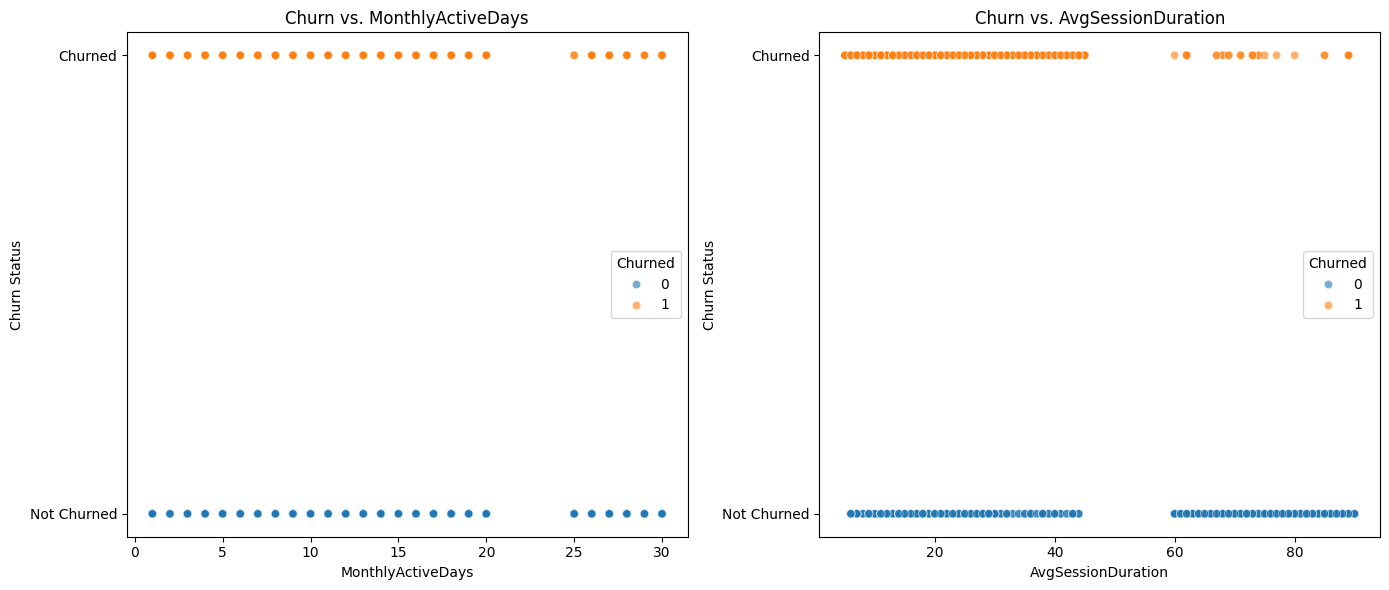

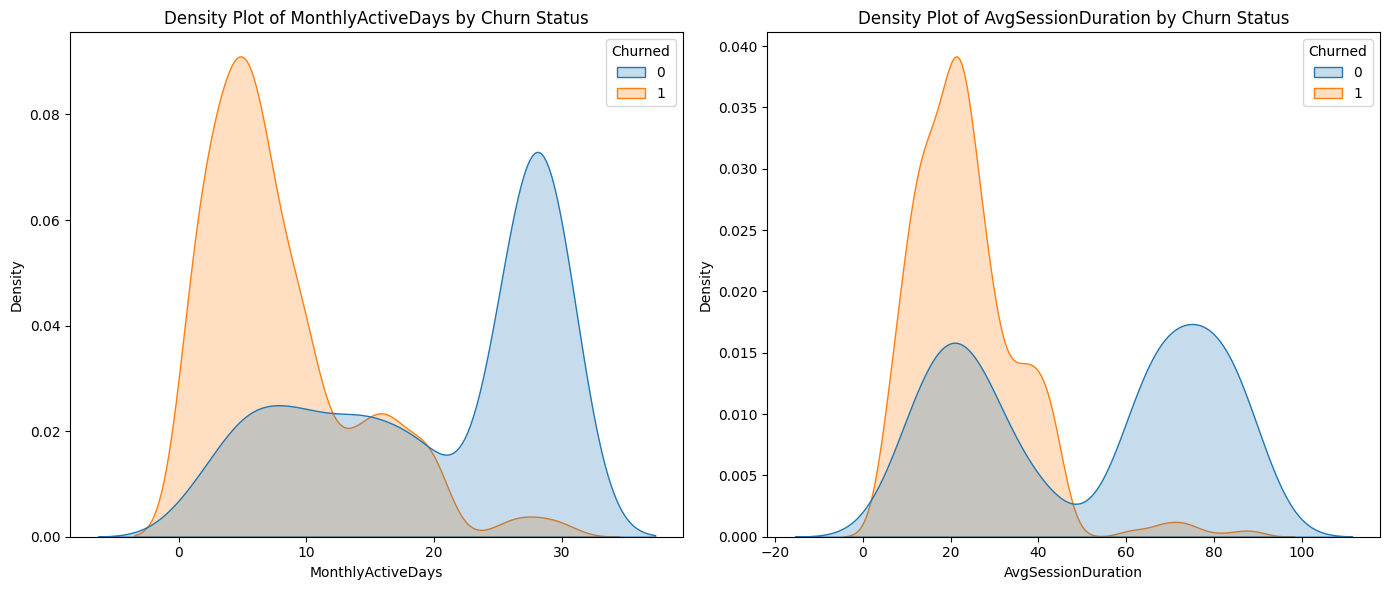

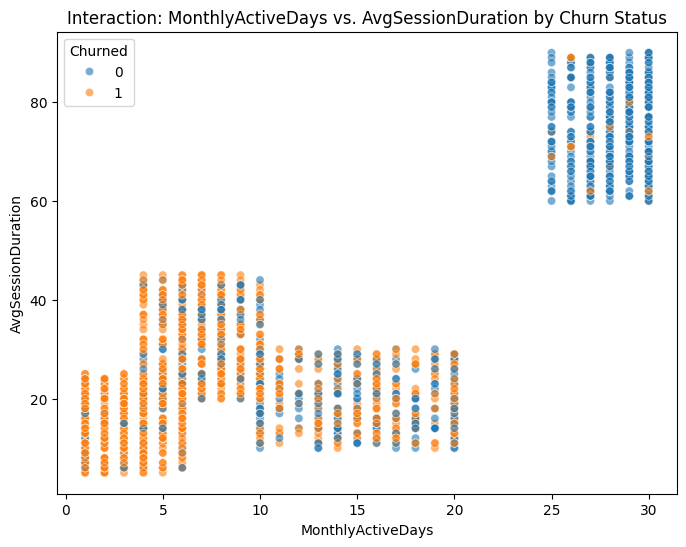

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the numeric variables to analyze
var1 = 'MonthlyActiveDays'
var2 = 'AvgSessionDuration'

# Visualize the relationship with churn using scatter plots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_sample, x=var1, y='Churned', hue='Churned', alpha=0.6)
plt.title(f'Churn vs. {var1}')
plt.yticks([0, 1], ['Not Churned', 'Churned'])
plt.xlabel(var1)
plt.ylabel('Churn Status')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_sample, x=var2, y='Churned', hue='Churned', alpha=0.6)
plt.title(f'Churn vs. {var2}')
plt.yticks([0, 1], ['Not Churned', 'Churned'])
plt.xlabel(var2)
plt.ylabel('Churn Status')

plt.tight_layout()
plt.show()


# Visualize distributions of these variables for churned vs. non-churned customers
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df_sample, x=var1, hue='Churned', fill=True, common_norm=False)
plt.title(f'Density Plot of {var1} by Churn Status')
plt.xlabel(var1)
plt.ylabel('Density')

plt.subplot(1, 2, 2)
sns.kdeplot(data=df_sample, x=var2, hue='Churned', fill=True, common_norm=False)
plt.title(f'Density Plot of {var2} by Churn Status')
plt.xlabel(var2)
plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Consider interaction between the two variables
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x=var1, y=var2, hue='Churned', alpha=0.6)
plt.title(f'Interaction: {var1} vs. {var2} by Churn Status')
plt.xlabel(var1)
plt.ylabel(var2)
plt.show()


### Observations of Nonlinear Patterns

From the scatter plots and density plots, we can observe the following non-linear patterns and interactions related to churn:

1.  **`MonthlyActiveDays` vs. Churn:**
    *   The density plot for `MonthlyActiveDays` shows that a high proportion of churned users tend to have very low monthly active days (e.g., 0-5 days). However, there's also a smaller, but noticeable, group of churned users at higher active days, possibly indicating different types of churn (e.g., disengagement vs. finding a better alternative after initial intense use).
    *   Non-churned users show a more spread-out distribution across various active days, with a peak in the mid-range.

2.  **`AvgSessionDuration` vs. Churn:**
    *   Similar to `MonthlyActiveDays`, the density for churned users is higher at very low average session durations. This suggests quick disengagement.
    *   However, there isn't a clear linear increase or decrease in churn probability with session duration. Users with very short sessions are likely to churn, but once they engage for a moderate amount of time, the relationship becomes more complex.

3.  **Interaction between `MonthlyActiveDays` and `AvgSessionDuration`:**
    *   The scatter plot combining both variables with churn as hue reveals regions where churned users are concentrated. For example, a high density of churned users exists where both `MonthlyActiveDays` and `AvgSessionDuration` are low. This could indicate users who try the app briefly and leave.
    *   Conversely, non-churned users are generally clustered in regions of higher `MonthlyActiveDays` and `AvgSessionDuration`. However, there are also some churned users in these higher-engagement areas, which a simple linear model or a shallow decision tree might struggle to distinguish. This suggests that the *combination* of these two features has a non-linear effect on churn.

These observations indicate that the decision boundary separating churned from non-churned users is likely not a simple straight line or a series of orthogonal cuts (as in a basic decision tree). Instead, it appears to be a more complex, curved, or multi-faceted boundary, justifying the use of models capable of capturing such intricate relationships.


### Justification for Neural Network over Decision Tree

Yes, the observed non-linear patterns justify using a Neural Network (NN) over a traditional Decision Tree (DT).

Decision Trees create decision boundaries through a series of axis-parallel splits. While an ensemble of trees (like Random Forests or Gradient Boosting) can approximate complex functions, a single, shallow Decision Tree (like the one used in Section E, with `max_depth=4`) might struggle to accurately capture the nuanced, non-linear relationships and interactions observed. For instance, a DT might make a split at `MonthlyActiveDays < 5` and `AvgSessionDuration < 10` but might miss the more subtle patterns where high values of both variables (e.g., `MonthlyActiveDays > 20` and `AvgSessionDuration > 60`) are also associated with a certain level of churn, or where specific combinations indicate different user segments.

Neural Networks, with their hidden layers and activation functions, are inherently designed to learn and approximate complex, non-linear functions. They can model intricate interactions between features without explicit feature engineering for every combination. The observed patterns, where both very low and potentially very high engagement levels might lead to churn, or where specific curvilinear regions indicate higher churn, are well-suited for a NN's ability to create curved and non-linear decision surfaces. The `Reduced NN` model, despite having fewer input features, performed very well, suggesting it effectively captured complex relationships within those features.

**Business Implication:**
Understanding these non-linear patterns allows for more targeted interventions. For example, instead of a blanket strategy for all low-engagement users, the business can differentiate between users who are merely inactive versus those who are highly engaged but still churning due to other, more complex factors. This could lead to a more efficient allocation of resources for retention campaigns, focusing on specific segments identified by these non-linear relationships (e.g., re-engagement campaigns for very low activity users, or customer service outreach for highly engaged but dissatisfied users).

**Analytical Limitation:**
One analytical limitation is the **interpretability of the non-linear relationships learned by the Neural Network**. While NNs can capture these complex patterns, explaining *why* a specific combination of `MonthlyActiveDays` and `AvgSessionDuration` leads to churn (i.e., identifying the exact decision rules or thresholds) is significantly harder than with a Decision Tree. The "black-box" nature of NNs makes it challenging to extract clear, human-understandable insights or direct causal relationships that could guide precise business actions beyond recognizing the pattern exists. This can hinder detailed post-hoc analysis and communication of insights to non-technical stakeholders.